In [78]:
import paddle 
import json

In [79]:
paddle.utils.run_check()

Running verify PaddlePaddle program ... 
PaddlePaddle works well on 1 GPU.
PaddlePaddle is installed successfully! Let's start deep learning with PaddlePaddle now.


/home/kenneth/.conda/envs/paddleocr/lib/python3.13/site-packages/paddle/pir/math_op_patch.py:241: UserWarning: Tensor do not have 'place' interface for pir graph mode, try not to use it. None will be returned.
  warnings.warn(


In [80]:
from paddleocr import PaddleOCR, PaddleOCRVL
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import os
from groq import Groq
from dotenv import load_dotenv

In [81]:
load_dotenv()
api_key = os.getenv("GROQ_API_KEY")
print(f"GROQ API Key: {api_key}")

GROQ API Key: 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


In [82]:
client = Groq(
    api_key=os.environ.get("GROQ_API_KEY"),
)

In [83]:
# connfigure showing image size
plt.rcParams['figure.figsize'] = [15, 10]

In [84]:
# load the model
ocr = PaddleOCR(use_angle_cls=True, lang='en') 

/tmp/ipykernel_64963/3392548086.py:2: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=True, lang='en')
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/kenneth/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/kenneth/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/kenneth/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `

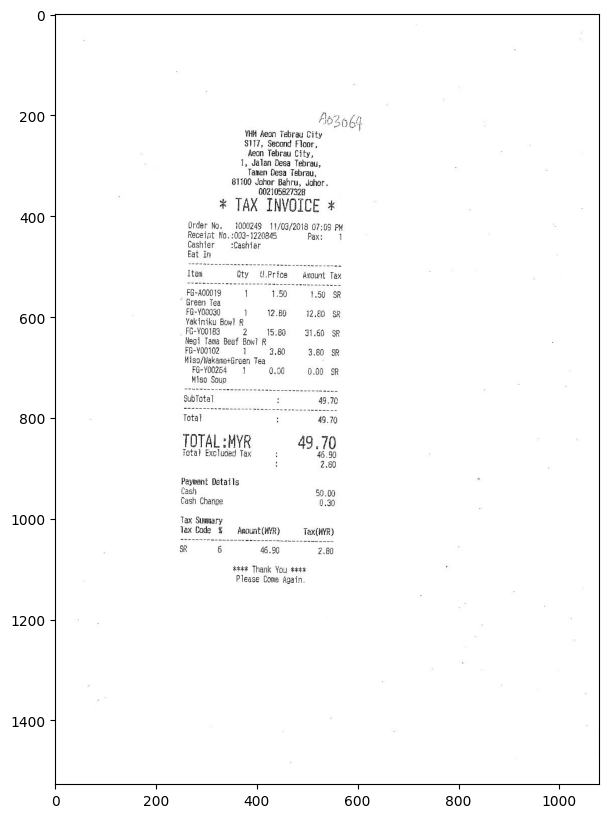

In [85]:
img_path = '/home/kenneth/Documents/College/Softeng/Finance/backend/src/infrastucture/AI/023.jpg'
image = Image.open(img_path).convert('RGB')
plt.imshow(image)

In [86]:
# load the image opencv2
img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
# apply the model on the image
result = ocr.predict(img_path)


In [87]:
page = result[0]
texts = page['rec_texts'] # recognized text strings
scores = page['rec_scores'] # confidence scores for each text line
boxes  = page['rec_polys'] #  bounding box coordinates

In [88]:
print(result[0])

{'input_path': '/home/kenneth/Documents/College/Softeng/Finance/backend/src/infrastucture/AI/023.jpg', 'page_index': None, 'doc_preprocessor_res': {'input_path': None, 'page_index': None, 'input_img': array([[[255, ..., 255],
        ...,
        [255, ..., 255]],

       ...,

       [[255, ..., 255],
        ...,
        [255, ..., 255]]], shape=(1527, 1080, 3), dtype=uint8), 'model_settings': {'use_doc_orientation_classify': True, 'use_doc_unwarping': True}, 'angle': 0, 'rot_img': array([[[255, ..., 255],
        ...,
        [255, ..., 255]],

       ...,

       [[255, ..., 255],
        ...,
        [255, ..., 255]]], shape=(1527, 1080, 3), dtype=uint8), 'output_img': array([[[255, ..., 255],
        ...,
        [255, ..., 255]],

       ...,

       [[255, ..., 255],
        ...,
        [255, ..., 255]]], shape=(1527, 1080, 3), dtype=uint8)}, 'dt_polys': [array([[288, 157],
       ...,
       [288, 181]], shape=(4, 2), dtype=int16), array([[286, 181],
       ...,
       [286, 

In [89]:
for text, score, box in zip(texts, scores, boxes):
    # box is a numpy array like [[x1, y1], [x2, y2], [x3, y3], [x4, y4]]
    coords = box.astype(int).tolist()  # convert to normal list of ints
    print(f"{text:25} | {score:.3f} | {coords}")

YHM Aeon Tebrau City      | 0.989 | [[288, 157], [474, 155], [475, 179], [288, 181]]
S117, Second Floor,       | 0.968 | [[286, 181], [462, 178], [463, 202], [286, 205]]
Aeon Tebrau City,         | 0.984 | [[296, 202], [455, 202], [455, 226], [296, 226]]
1, Jalan Desa Tebrau,     | 0.975 | [[279, 225], [471, 225], [471, 249], [279, 249]]
Taman Desa Tebrau,        | 0.994 | [[295, 250], [460, 250], [460, 270], [295, 270]]
81100 Johor Bahru, Johor. | 0.982 | [[259, 270], [487, 266], [488, 293], [259, 296]]
002105827328              | 0.999 | [[322, 292], [436, 292], [436, 316], [322, 316]]
*                         | 0.949 | [[227, 313], [258, 313], [258, 350], [227, 350]]
TAX INVOICE *             | 0.993 | [[265, 314], [509, 311], [509, 352], [265, 355]]
Order No.                 | 0.973 | [[164, 372], [263, 372], [263, 393], [164, 393]]
1000249 11/03/2018 07:09 PM | 0.980 | [[268, 370], [520, 367], [520, 391], [268, 394]]
Receipt No.:003-1220845   | 0.998 | [[162, 394], [371, 391], [3

In [90]:
# 1. First, we extract the data and find the center point of each box
parsed_items = []
for text, score, box in zip(texts, scores, boxes):
    # box format is [[x1, y1], [x2, y2], [x3, y3], [x4, y4]]
    # Top-left y is box[0][1], bottom-left y is box[3][1]
    
    y_center = (box[0][1] + box[3][1]) / 2  # Calculate vertical center
    x_left = box[0][0]                      # Keep the left-most x coordinate
    
    parsed_items.append({
        'text': text,
        'y_center': y_center,
        'x_left': x_left
    })

# 2. Sort all items from top to bottom based on their y_center
parsed_items.sort(key=lambda item: item['y_center'])

# 3. Group items that are on the same line
lines = []
current_line = []
y_tolerance = 15 # Adjust this if lines are bleeding together or splitting

for item in parsed_items:
    if not current_line:
        current_line.append(item)
    else:
        # Check if the current item is on the same vertical line as the previous item
        last_item = current_line[-1]
        if abs(item['y_center'] - last_item['y_center']) <= y_tolerance:
            current_line.append(item)
        else:
            # It's a new line, so save the old one and start a new one
            lines.append(current_line)
            current_line = [item]

if current_line:
    lines.append(current_line)

final_text = ""

# 4. Sort each line from left to right, then format and print
for line in lines:
    # Sort by the x coordinate so the item name comes before the price
    line.sort(key=lambda item: item['x_left'])
    
    # Extract just the text strings
    line_texts = [item['text'] for item in line]
    
    # If there are exactly two items (like Item + Price), format with a colon
    if len(line_texts) == 2:
        final_text += f"{line_texts[0]} : {line_texts[1]}\n"
        print(f"{line_texts[0]} : {line_texts[1]}")
    else:
        # Otherwise, just print the line normally
        final_text += " ".join(line_texts) + "\n"
        print(" ".join(line_texts))

YHM Aeon Tebrau City
S117, Second Floor,
Aeon Tebrau City,
1, Jalan Desa Tebrau,
Taman Desa Tebrau,
81100 Johor Bahru, Johor.
002105827328
* : TAX INVOICE *
Order No. : 1000249 11/03/2018 07:09 PM
Receipt No.:003-1220845 Pax: 1
Cashier : :Cashiar
Eat In
Iteni Qty U.Price Ainount Tax
FG-A00019 1 1.50 1.50 SR
Green Tea FG-Y00030 1 12.80 12.80 SR
Yakiniku Bowl R FG-Y00163 2 15:80 31.60 SR
Negi Tama Beef Bowi R FG-Y00102 1 3.80 3.80 SR
Miso/Wakame+Green Tea FG-Y00264 1 0.00 0.00 SR
Miso Soup
SubTotal - 49.70
Total : 49.70
TOTAL:MYR : 49.70
Total Excluded Tax : 46.90
 : 2.80
Payment Details
Cash : 50.00
Cash Change : 0.30
Tax Summary
Tax Code % Amount(MYR) Tax(MYR)
SR 6 46.90 2.80
**** Thank You ****
Please Come Again.


In [91]:
# 1. First, we extract the data, center points, AND right-side coordinates
parsed_items = []
for text, score, box in zip(texts, scores, boxes):
    y_center = (box[0][1] + box[3][1]) / 2  
    x_left = box[0][0]                      
    x_right = box[1][0] # ADDED: Keep track of where the text ends
    
    parsed_items.append({
        'text': text,
        'y_center': y_center,
        'x_left': x_left,
        'x_right': x_right # ADDED
    })

# 2. Sort all items from top to bottom
parsed_items.sort(key=lambda item: item['y_center'])

# 3. Group items that are on the same line
lines = []
current_line = []
y_tolerance = 15 

for item in parsed_items:
    if not current_line:
        current_line.append(item)
    else:
        last_item = current_line[-1]
        if abs(item['y_center'] - last_item['y_center']) <= y_tolerance:
            current_line.append(item)
        else:
            lines.append(current_line)
            current_line = [item]

if current_line:
    lines.append(current_line)

final_text = ""

# 4. Sort left-to-right and inject proportional spaces
char_width = 12 # Adjust this: average pixel width of a single character

for line in lines:
    line.sort(key=lambda item: item['x_left'])
    
    line_str = ""
    prev_x_right = 0
    
    for i, item in enumerate(line):
        if i == 0:
            # First item on the line, just add it
            line_str += item['text']
        else:
            # Calculate the empty pixel gap between this item and the last one
            gap_pixels = item['x_left'] - prev_x_right
            
            # Figure out how many space characters fit in that gap
            # max(1, ...) ensures we always put at least 1 space, even if boxes overlap
            num_spaces = max(1, int(gap_pixels / char_width)) 
            
            # Add the spaces, then the text
            line_str += (" " * num_spaces) + item['text']
            
        # Update prev_x_right for the next item in the loop
        prev_x_right = item['x_right']
        
    final_text += line_str + "\n"
    print(line_str)

YHM Aeon Tebrau City
S117, Second Floor,
Aeon Tebrau City,
1, Jalan Desa Tebrau,
Taman Desa Tebrau,
81100 Johor Bahru, Johor.
002105827328
* TAX INVOICE *
Order No. 1000249 11/03/2018 07:09 PM
Receipt No.:003-1220845     Pax:  1
Cashier  :Cashiar
Eat In
Iteni     Qty U.Price  Ainount Tax
FG-A00019   1   1.50   1.50 SR
Green Tea FG-Y00030   1   12.80   12.80 SR
Yakiniku Bowl R FG-Y00163   2   15:80   31.60 SR
Negi Tama Beef Bowi R FG-Y00102   1   3.80   3.80 SR
Miso/Wakame+Green Tea FG-Y00264  1   0.00   0.00 SR
Miso Soup
SubTotal           -      49.70
Total             :       49.70
TOTAL:MYR        49.70
Total Excluded Tax    :       46.90
        2.80
Payment Details
Cash                      50.00
Cash Change                  0.30
Tax Summary
Tax Code %  Amount(MYR)   Tax(MYR)
SR     6      46.90      2.80
**** Thank You ****
Please Come Again.


In [93]:
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile", # Specifying the open model hosted on Groq
    messages=[
        {
            "role": "system", 
            "content": "Extract the food items, prices, and quantities from this receipt into a JSON array. Ignore product codes, only extract the human readable and sensible information like the items name that are real and not the items code. The JSON should be in the format: [{\"item\": \"item name\", \"price\": \"price\", \"quantity\": \"quantity\"}, ...], and only return the JSON array without any additional text."
        },
        {
            "role": "user", 
            "content": final_text
        }
    ]
)

print(response.choices[0].message.content)

[2026-03-22 19:39:05,529] [    INFO] _client.py:1025 - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


[
{"item": "Green Tea", "price": "12.80", "quantity": "1"},
{"item": "Yakiniku Bowl R", "price": "15.80", "quantity": "2"},
{"item": "Negi Tama Beef Bowi R", "price": "3.80", "quantity": "1"},
{"item": "Miso/Wakame+Green Tea", "price": "0.00", "quantity": "1"},
{"item": "Miso Soup", "price": "1.50", "quantity": "1"}
]
